# Model Creation

### Steps 
* imported all the required libraries
* imported the dataset
* data pre processing
* EDA
* data split (train_test_split)
* model training
* efficiency evaluation

In [48]:
import numpy as np
import pandas as pd 
import seaborn as sns

In [82]:
# Loading the tips dataset using seaborn
tip=sns.load_dataset("tips")

In [ ]:
# how the data looks?
tip.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [ ]:
#how the data looks?
tip.tail()

,total_bill,tip,sex,smoker,day,time,size
239,29.03,5.92,Male,No,Sat,Dinner,3
240,27.18,2.00,Female,Yes,Sat,Dinner,2
241,22.67,2.00,Male,Yes,Sat,Dinner,2
242,17.82,1.75,Male,No,Sat,Dinner,2
243,18.78,3.00,Female,No,Thur,Dinner,2


In [ ]:
#how the data looks?
tip.sample(4)

,total_bill,tip,sex,smoker,day,time,size
62,11.02,1.98,Male,Yes,Sat,Dinner,2
149,7.51,2.00,Male,No,Thur,Lunch,2
105,15.36,1.64,Male,Yes,Sat,Dinner,2
152,17.26,2.74,Male,No,Sun,Dinner,3


In [ ]:
# how the data looks?
tip.info()

<class 'pandas.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


In [ ]:
# what are the columns name?
tip.columns

Index(['total_bill', 'tip', 'sex', 'smoker', 'day', 'time', 'size'], dtype='str')

In [ ]:
# how the data looks mathematically?
tip["total_bill"].describe()

count    244.000000
mean      19.785943
std        8.902412
min        3.070000
25%       13.347500
50%       17.795000
75%       24.127500
max       50.810000
Name: total_bill, dtype: float64

In [ ]:
# how the data looks mathematically?
tip["tip"].describe()

count    244.000000
mean       2.998279
std        1.383638
min        1.000000
25%        2.000000
50%        2.900000
75%        3.562500
max       10.000000
Name: tip, dtype: float64

In [ ]:
#how the data looks mathematically?
tip["size"].describe()

count    244.000000
mean       2.569672
std        0.951100
min        1.000000
25%        2.000000
50%        2.000000
75%        3.000000
max        6.000000
Name: size, dtype: float64

In [ ]:
# is there any duplicate value?
tip[tip.duplicated()]

,total_bill,tip,sex,smoker,day,time,size
202,13.0,2.0,Female,Yes,Thur,Lunch,2


In [ ]:
# data cleaning: Untidy (accuracy) 
tip.drop_duplicates(inplace=True)

In [ ]:
# checking or testing if the cleaning code actually works
tip.duplicated().sum()

np.int64(0)

### lit bit of EDA 

<Axes: xlabel='total_bill', ylabel='Count'>

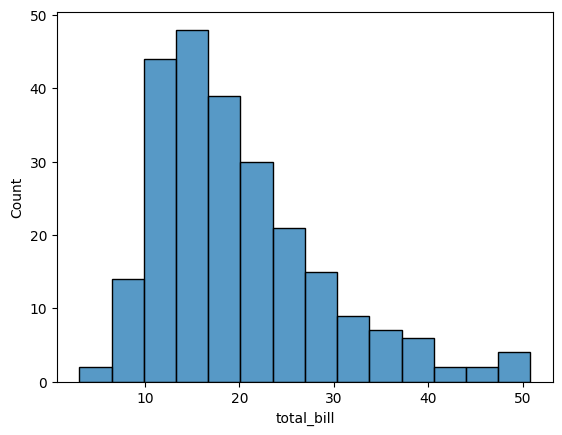

In [ ]:
# Univariate Analysis 
# When you have numerical data you make histplot to see the distribution 
sns.histplot(data=tip, x="total_bill")

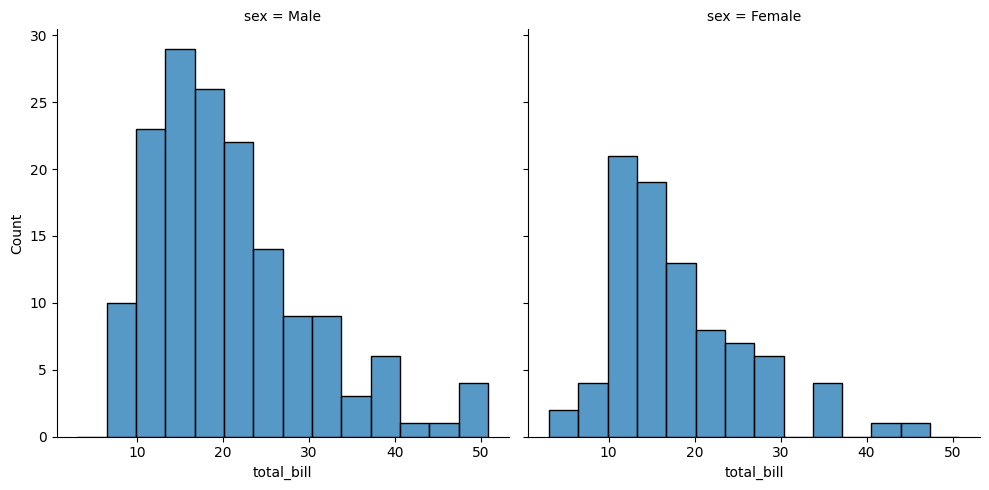

In [ ]:
#total_bill
sns.displot(data=tip, kind="hist", x="total_bill", col="sex", col_wrap=2)

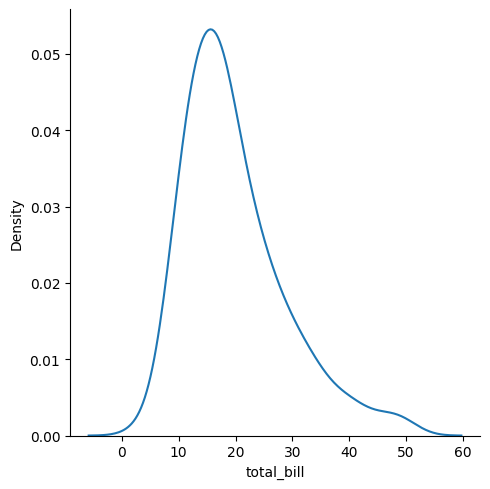

In [ ]:
#total_bill
sns.displot(data=tip, kind="kde",x="total_bill")

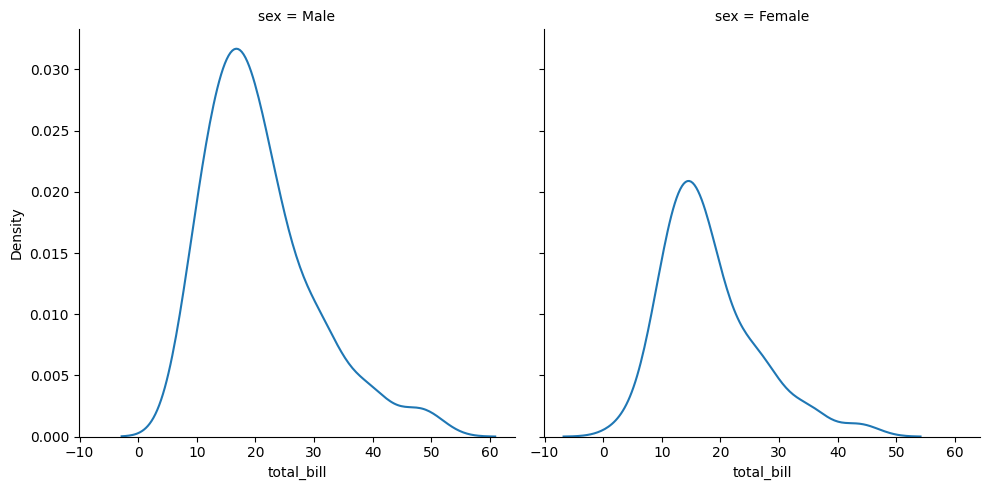

In [ ]:
#total_bill
sns.displot(data=tip, kind="kde",x="total_bill", col="sex",col_wrap=2)

<Axes: xlabel='total_bill'>

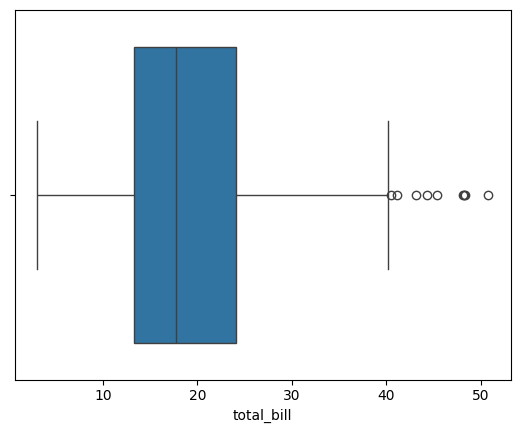

In [ ]:
# total_bill
sns.boxplot(data=tip, x="total_bill")

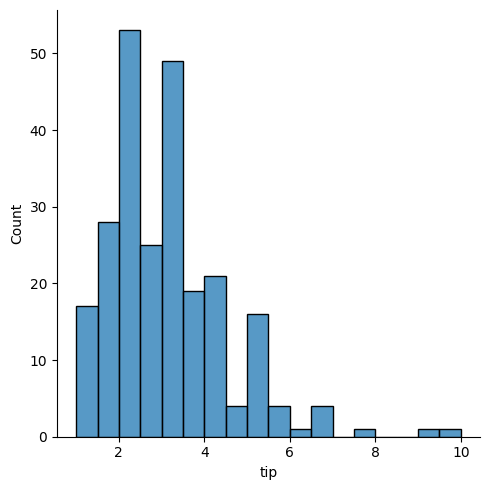

In [ ]:
# tip
sns.displot(data=tip,x="tip",kind="hist")

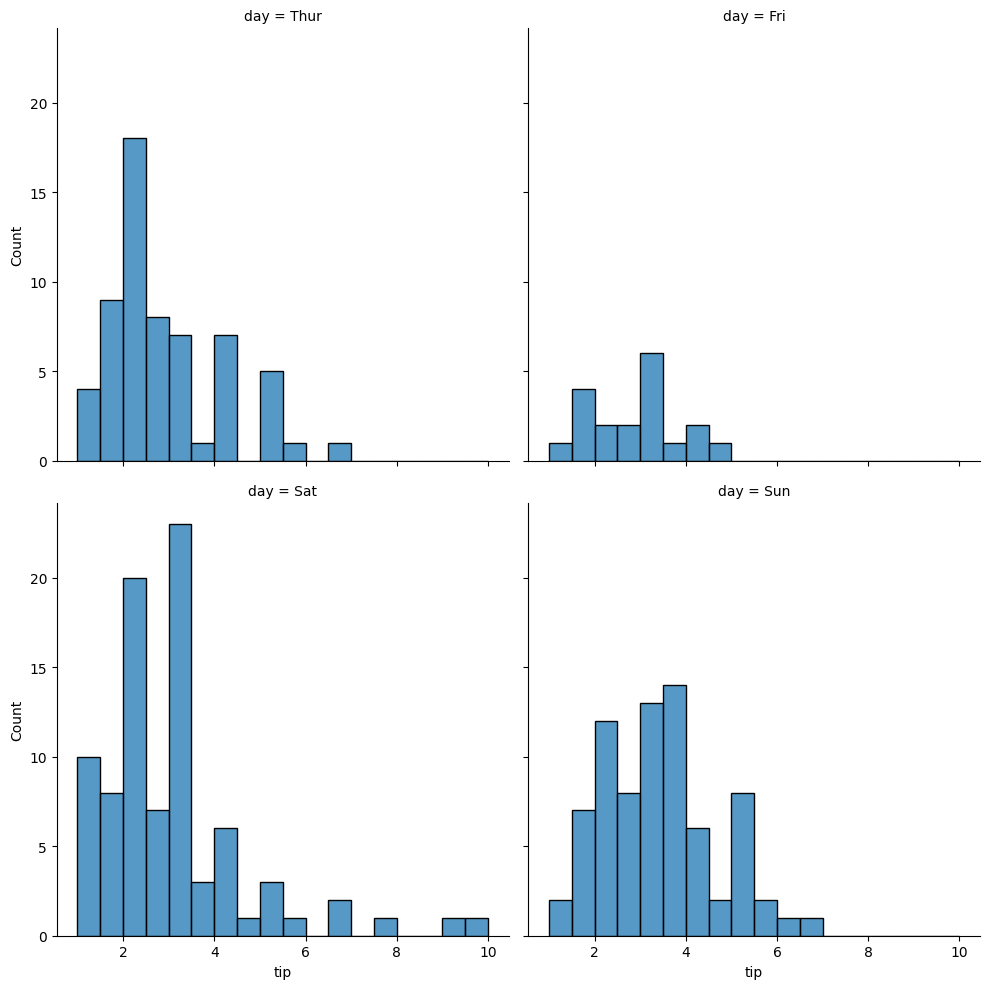

In [ ]:
#tip
sns.displot(data=tip, x="tip", col="day", col_wrap=2)

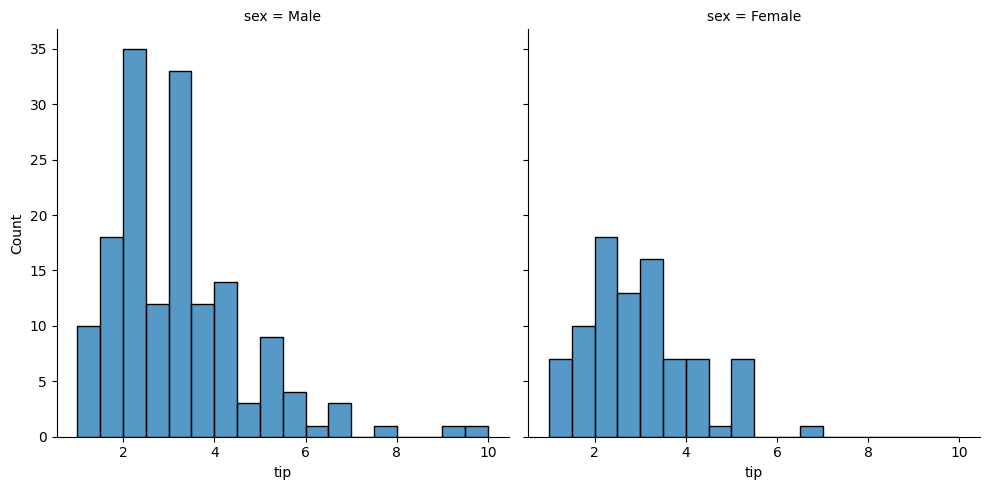

In [ ]:
# tip
sns.displot(data=tip, x="tip",kind="hist",col="sex",col_wrap=2)

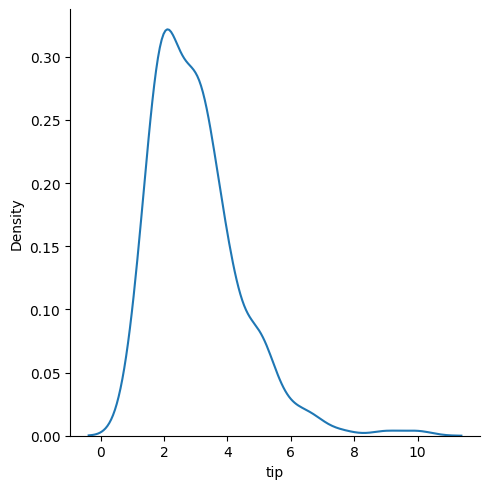

In [ ]:
# tip
sns.displot(data=tip, x="tip",kind="kde")

<Axes: ylabel='tip'>

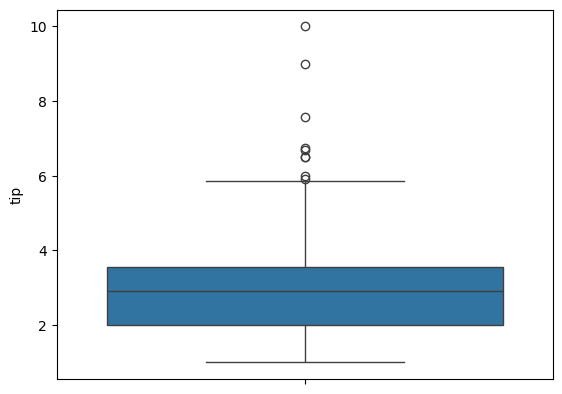

In [ ]:
# tip
sns.boxplot(data=tip, y="tip")

### Multivariate Analysis

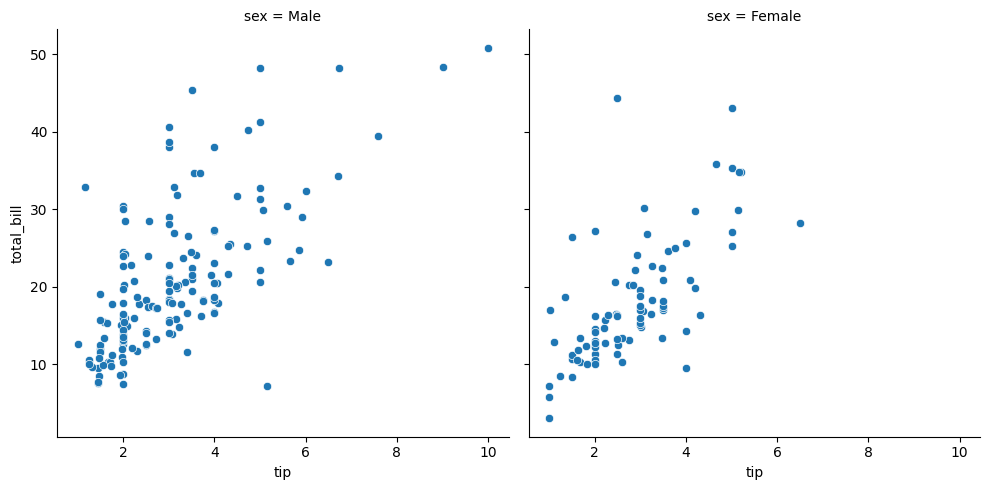

In [36]:
sns.relplot(data=tip, x="tip",y="total_bill",kind="scatter",col="sex",col_wrap=2)

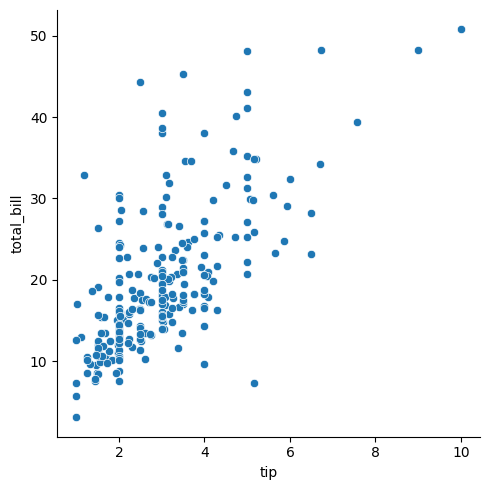

In [37]:
sns.relplot(data=tip, x="tip",y="total_bill")

<Axes: xlabel='tip', ylabel='total_bill'>

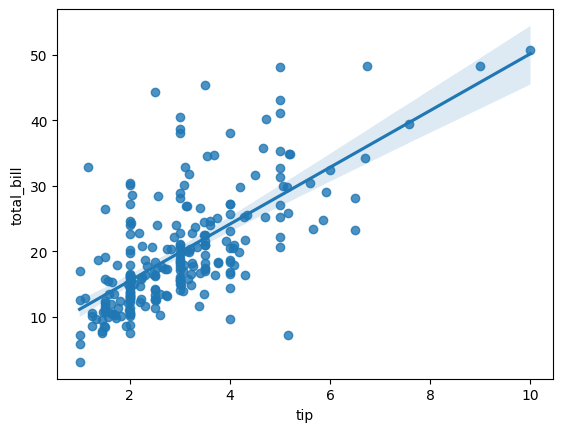

In [41]:
sns.regplot(data=tip, x="tip",y="total_bill")

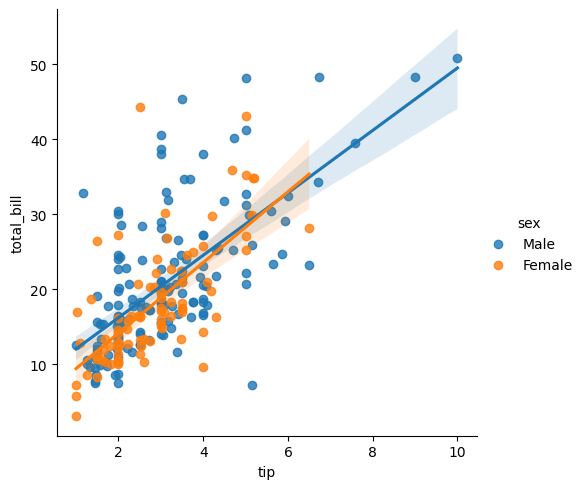

In [40]:
sns.lmplot(data=tip, x="tip",y="total_bill",hue="sex")

<Axes: xlabel='tip', ylabel='total_bill'>

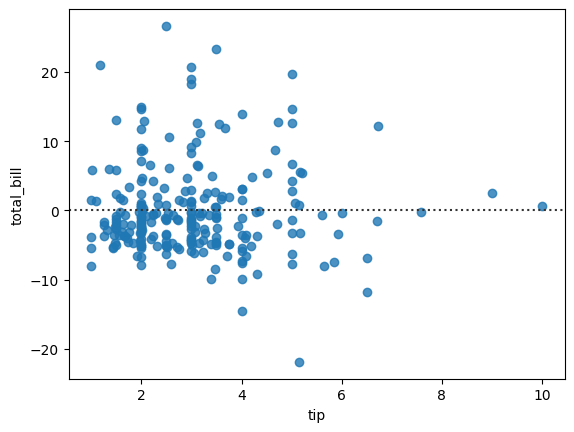

In [46]:
sns.residplot(data=tip, x="tip", y="total_bill")

In [50]:
tip.info()

<class 'pandas.DataFrame'>
Index: 243 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  243 non-null    float64 
 1   tip         243 non-null    float64 
 2   sex         243 non-null    category
 3   smoker      243 non-null    category
 4   day         243 non-null    category
 5   time        243 non-null    category
 6   size        243 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 9.1 KB


### Planning to make a model : Linear Regression

In [ ]:
# Converted Columns in to numpuy array for splitting the data into train and test 
x=np.array([tip.total_bill])
y=np.array([tip.tip])

In [ ]:
# trying to manage the shape of the array
x=x.reshape(243,1)
y=y.reshape(243,1)

In [ ]:
#checking why the error has occured in train_test_split
print(type(x))
print(x.ndim)
print(x.shape)

<class 'numpy.ndarray'>
2
(243, 1)


### Splitting the data : TRAIN_TEST_SPLIT

In [64]:
from sklearn.model_selection import train_test_split
X_train, X_test, Y_train, Y_test=train_test_split(x,y, test_size=0.2, random_state=42)

### Data Feeding to model to make it learn

In [ ]:
from sklearn import linear_model

model=linear_model.LinearRegression().fit(X_train,Y_train)

In [ ]:
# Any random prediction
model.predict(np.array([[16.09]]))

array([[2.64100577]])

In [ ]:
# Generated Prediction on Test dataset
prediction=model.predict(np.array(X_test))

In [ ]:
# to test the efficiency of the model (accuracy) 
# we cannot find accuracy directly of linear regression model (numerical data) so R2_score and other methods as well are there
from sklearn import metrics
r2_score=metrics.r2_score(Y_test, prediction)

In [ ]:
# this means model is evaluating 50% correctly 
r2_score

0.5276979930058592